In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [3]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [4]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [5]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 9)
Val shape: (124750, 9)
Unseen shape: (125248, 9)


In [6]:
# export and remove unseen

unseen_df.to_csv("data/unseen_holdout_raw.csv", index=False)

df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

df_raw_dev = df.copy()

Model dataframe shape: (499550, 9)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


In [7]:
# feature engineering function

import numpy as np

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    # simple 1 day return
    panel_df["ret_1"] = g["Close"].pct_change()

    # target: std of stock's daily returns from t+1 to t+21
    panel_df["target_vol_21d"] = (
        g["ret_1"].transform(lambda s: s.shift(-1).rolling(21).std().shift(-20))
    )

    # today's absolute return
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    # std of returns over past 5, 10, 21 days
    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    # daily intraday range
    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    # relative volume
    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df


In [8]:
# apply feature engineering to dev set
df = engineer_features(df)

feature_cols = [
    "ret_abs_1",
    "ret_std_5",
    "ret_std_10",
    "ret_std_21",
    "hl_range_mean_5",
    "hl_range_mean_21",
    "vol_rel_5",
    "vol_rel_21",
]

target_col = "target_vol_21d"


In [9]:
# just look at features and target for now

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security',
       'Sector', 'ret_1', 'target_vol_21d', 'ret_abs_1', 'ret_std_5',
       'ret_std_10', 'ret_std_21', 'hl_range', 'hl_range_mean_5',
       'hl_range_mean_21', 'vol_mean_5', 'vol_rel_5', 'vol_mean_21',
       'vol_rel_21'],
      dtype='object')

In [10]:
# create train/val sets for modeling

LOOKBACK = 21
HORIZON = 21

# drop missing / non-finite once
df_feat = df.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(df_feat[feature_cols + [target_col]]).all(axis=1)
df_feat = df_feat.loc[finite_mask].copy()

# keep rows whose endpoint date is in the split
# AND whose forward target window stays inside the split
#
# because target at date t uses returns from t+1 ... t+21

# use per-symbol forward availability instead of calendar days
df_feat = df_feat.sort_values(["Symbol", "Date"]).copy()
g = df_feat.groupby("Symbol")

# next date after horizon steps, used only as a guard
df_feat["date_plus_horizon"] = g["Date"].shift(-HORIZON)

# training rows: endpoint in train, and full forward target remains in train
train_feat = df_feat[
    (df_feat["Date"] >= TRAIN_START) &
    (df_feat["Date"] <= TRAIN_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= TRAIN_END)
].copy()

# validation rows: endpoint in val, and full forward target remains in val
val_feat = df_feat[
    (df_feat["Date"] >= VAL_START) &
    (df_feat["Date"] <= VAL_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= VAL_END)
].copy()

print("train_feat:", train_feat.shape)
print("val_feat:", val_feat.shape)


train_feat: (353821, 23)
val_feat: (103781, 23)


In [11]:
LOOKBACK = 21

def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    panel_df = panel_df.sort_values(["Symbol", "Date"]).copy()

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].to_numpy(dtype=np.float32)
        y_values = g[target_col].to_numpy(dtype=np.float32)
        dates = g["Date"].to_numpy()

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]
            end_date = dates[t]

            if not np.isfinite(X_window).all():
                continue
            if not np.isfinite(y_target):
                continue

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": end_date
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [12]:
# train sequences
X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_train["Date"] = pd.to_datetime(meta_train["Date"])

print("Train:", X_train.shape, y_train.shape)

# validation sequences with train context
train_context = (
    train_feat
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

val_with_context = (
    pd.concat([train_context, val_feat], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

X_val_all, y_val_all, meta_val_all = make_sequences(
    val_with_context,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_val_all["Date"] = pd.to_datetime(meta_val_all["Date"])

val_keep = (
    (meta_val_all["Date"] >= VAL_START) &
    (meta_val_all["Date"] <= VAL_END)
)

X_val = X_val_all[val_keep.values]
y_val = y_val_all[val_keep.values]
meta_val = meta_val_all.loc[val_keep].reset_index(drop=True)

print("Val:", X_val.shape, y_val.shape)

Train: (343841, 21, 8) (343841,)
Val: (103781, 21, 8) (103781,)


In [13]:
# scale features and target using train only

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [14]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,793 (22.63 KB)

 Trainable params: 5,793 (22.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - loss: 0.4373 - mae: 0.4502 - val_loss: 0.5773 - val_mae: 0.4899
Epoch 2/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.4140 - mae: 0.4402 - val_loss: 0.5759 - val_mae: 0.4905
Epoch 3/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.4041 - mae: 0.4358 - val_loss: 0.5775 - val_mae: 0.4908
Epoch 4/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.3952 - mae: 0.4320 - val_loss: 0.5814 - val_mae: 0.4899
Epoch 5/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 0.3861 - mae: 0.4287 - val_loss: 0.5846 - val_mae: 0.4926
Epoch 6/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 0.3769 - mae: 0.4259 - val_loss: 0.5853 - val_mae: 0.4914
Epoch 7/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 0.3687 - mae: 0.4233 - val_loss: 0.5864 - val_mae: 0.4925


In [16]:
val_pred_scaled = model.predict(X_val_scaled).reshape(-1)
val_pred = val_pred_scaled * y_std + y_mean

val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

val_results.head()

3244/3244 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


,Symbol,Date,y_true,y_pred
0,A,2024-03-21,0.014448,0.016806
1,A,2024-03-22,0.017340,0.015791
2,A,2024-03-25,0.017325,0.016104
3,A,2024-03-26,0.017329,0.016345
4,A,2024-03-27,0.016776,0.016473


In [17]:
# compute valuation metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(val_results["y_true"], val_results["y_pred"]))
mae = mean_absolute_error(val_results["y_true"], val_results["y_pred"])

print("Validation RMSE:", rmse)
print("Validation MAE:", mae)

Validation RMSE: 0.007182013574546647
Validation MAE: 0.0046423557214438915


In [18]:
# check correlation

corr = val_results["y_true"].corr(val_results["y_pred"])
print("Validation correlation:", corr)

Validation correlation: 0.6086625881503555


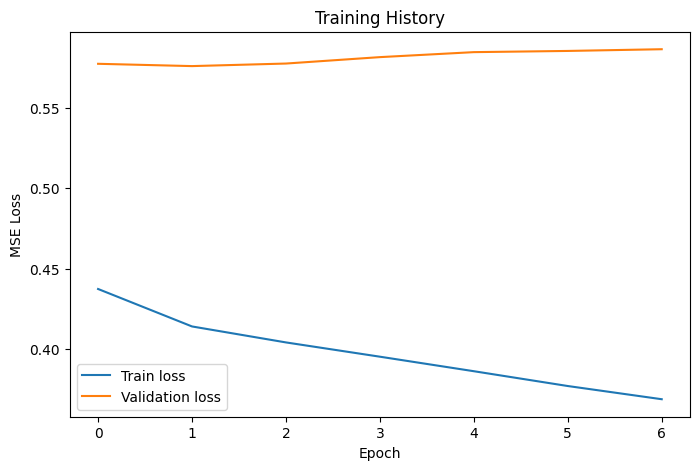

In [19]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

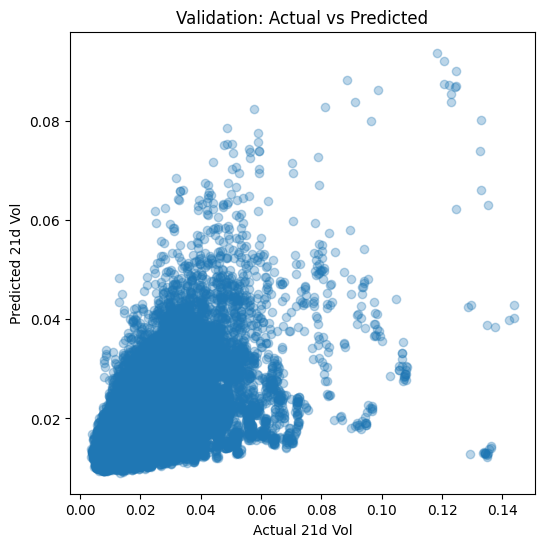

In [20]:
# plot actual vs predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(val_results["y_true"], val_results["y_pred"], alpha=0.3)
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Validation: Actual vs Predicted")
plt.show()

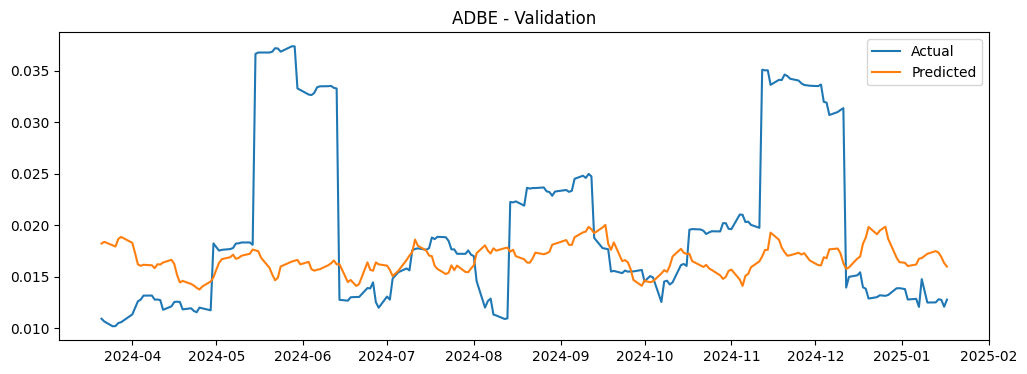

In [21]:
# inspect predictions for a sample stock

sample_symbol = val_results["Symbol"].iloc[1650]

tmp = val_results[val_results["Symbol"] == sample_symbol].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(tmp["Date"], tmp["y_true"], label="Actual")
plt.plot(tmp["Date"], tmp["y_pred"], label="Predicted")
plt.title(f"{sample_symbol} - Validation")
plt.legend()
plt.show()

In [22]:
# baseline comparison - use past 21d volatility as naive predictor

baseline_results = meta_val.copy()
baseline_results = baseline_results.merge(
    val_feat[["Symbol", "Date", "ret_std_21", target_col]],
    on=["Symbol", "Date"],
    how="left"
)

baseline_results["baseline_pred"] = baseline_results["ret_std_21"]
baseline_results["y_true"] = baseline_results[target_col]

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_results["y_true"],
    baseline_results["baseline_pred"]
))
baseline_mae = mean_absolute_error(
    baseline_results["y_true"],
    baseline_results["baseline_pred"]
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 0.009551354546655235
Baseline MAE: 0.006199224649093266


In [23]:
val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

baseline_map = val_feat[["Symbol", "Date", "ret_std_21"]].copy()
val_results = val_results.merge(baseline_map, on=["Symbol", "Date"], how="left")
val_results["baseline_pred"] = val_results["ret_std_21"]

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rows = []
for symbol, g in val_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "n": len(g)
    })

by_stock = pd.DataFrame(rows)
by_stock["rmse_win"] = by_stock["rmse_lstm"] < by_stock["rmse_baseline"]
by_stock["mae_win"] = by_stock["mae_lstm"] < by_stock["mae_baseline"]

print("Pct stocks where LSTM wins on RMSE:", by_stock["rmse_win"].mean())
print("Pct stocks where LSTM wins on MAE:", by_stock["mae_win"].mean())

by_stock.head()

Pct stocks where LSTM wins on RMSE: 0.9138276553106213
Pct stocks where LSTM wins on MAE: 0.8837675350701403


,Symbol,rmse_lstm,rmse_baseline,mae_lstm,mae_baseline,n,rmse_win,mae_win
0,A,0.004898,0.005941,0.004168,0.005041,208,True,True
1,AAPL,0.004835,0.005028,0.004048,0.003979,208,True,False
2,ABBV,0.007380,0.010069,0.004887,0.006817,208,True,True
3,ABNB,0.007386,0.010866,0.004824,0.008507,208,True,True
4,ABT,0.004367,0.005231,0.003691,0.004335,208,True,True


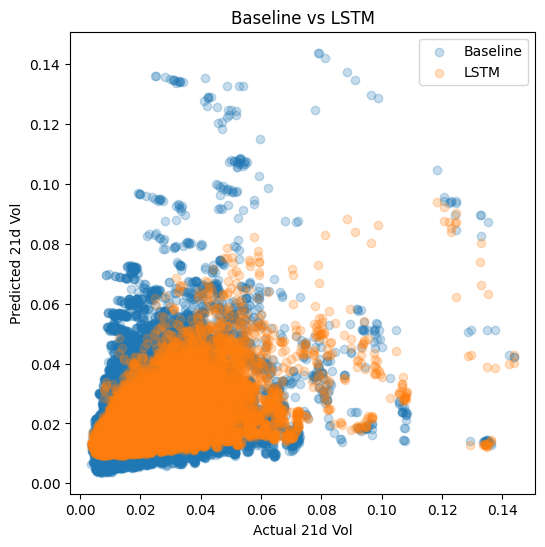

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(val_results["y_true"], val_results["baseline_pred"], alpha=0.25, label="Baseline")
plt.scatter(val_results["y_true"], val_results["y_pred"], alpha=0.25, label="LSTM")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Baseline vs LSTM")
plt.legend()
plt.show()

In [26]:
print("LSTM corr:", val_results["y_true"].corr(val_results["y_pred"]))
print("Baseline corr:", val_results["y_true"].corr(val_results["baseline_pred"]))

LSTM corr: 0.6086625881503555
Baseline corr: 0.4379502687275839


In [27]:
# unseen setup: build raw context first, then engineer features

unseen_df = pd.read_csv("data/unseen_holdout_raw.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

# IMPORTANT:
# use the RAW dev dataframe here, not the cleaned modeling dataframe
# this raw dev dataframe should be the train+val OHLCV panel before feature engineering/dropna
#
# If your raw dev dataframe is currently called df_raw_dev, use that.
# If not, create it earlier and keep it unchanged.

dev_context_raw = (
    df_raw_dev
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

unseen_raw_with_context = (
    pd.concat([dev_context_raw, unseen_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

# engineer features AFTER raw context is appended
unseen_feat_all = engineer_features(unseen_raw_with_context)

# keep only actual unseen rows
unseen_feat = unseen_feat_all[
    (unseen_feat_all["Date"] >= UNSEEN_START) &
    (unseen_feat_all["Date"] <= UNSEEN_END)
].copy()

unseen_feat = unseen_feat.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(unseen_feat[feature_cols + [target_col]]).all(axis=1)
unseen_feat = unseen_feat.loc[finite_mask].copy()

print("unseen_feat:", unseen_feat.shape)

2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 9)
Stocks: 499
unseen_feat: (114270, 22)


In [28]:
# unseen sequences from engineered panel that already includes raw dev context
X_unseen_all, y_unseen_all, meta_unseen_all = make_sequences(
    unseen_feat_all,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_unseen_all["Date"] = pd.to_datetime(meta_unseen_all["Date"])

unseen_keep = (
    (meta_unseen_all["Date"] >= UNSEEN_START) &
    (meta_unseen_all["Date"] <= UNSEEN_END)
)

X_unseen = X_unseen_all[unseen_keep.values]
y_unseen = y_unseen_all[unseen_keep.values]
meta_unseen = meta_unseen_all.loc[unseen_keep].reset_index(drop=True)

print("Unseen:", X_unseen.shape, y_unseen.shape)

Unseen: (104290, 21, 8) (104290,)


In [29]:
# scale unseen using train only

X_unseen_scaled = (X_unseen - feature_means) / feature_stds

# predict on unseen

unseen_pred_scaled = model.predict(X_unseen_scaled).reshape(-1)
unseen_pred = unseen_pred_scaled * y_std + y_mean

3260/3260 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [30]:
unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

In [31]:
baseline_map_unseen = unseen_feat[["Symbol", "Date", "ret_std_21"]].copy()

unseen_results = unseen_results.merge(
    baseline_map_unseen,
    on=["Symbol", "Date"],
    how="left"
)

unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

unseen_rmse = np.sqrt(mean_squared_error(unseen_results["y_true"], unseen_results["y_pred"]))
unseen_mae = mean_absolute_error(unseen_results["y_true"], unseen_results["y_pred"])
unseen_corr = unseen_results["y_true"].corr(unseen_results["y_pred"])

baseline_unseen_rmse = np.sqrt(mean_squared_error(unseen_results["y_true"], unseen_results["baseline_pred"]))
baseline_unseen_mae = mean_absolute_error(unseen_results["y_true"], unseen_results["baseline_pred"])
baseline_unseen_corr = unseen_results["y_true"].corr(unseen_results["baseline_pred"])

print("UNSEEN LSTM RMSE:", unseen_rmse)
print("UNSEEN LSTM MAE:", unseen_mae)
print("UNSEEN LSTM corr:", unseen_corr)

print("UNSEEN Baseline RMSE:", baseline_unseen_rmse)
print("UNSEEN Baseline MAE:", baseline_unseen_mae)
print("UNSEEN Baseline corr:", baseline_unseen_corr)

UNSEEN LSTM RMSE: 0.007606789001141336
UNSEEN LSTM MAE: 0.005225539207458496
UNSEEN LSTM corr: 0.5707364889929437
UNSEEN Baseline RMSE: 0.010426150222109593
UNSEEN Baseline MAE: 0.006896895107065282
UNSEEN Baseline corr: 0.41953239989333607


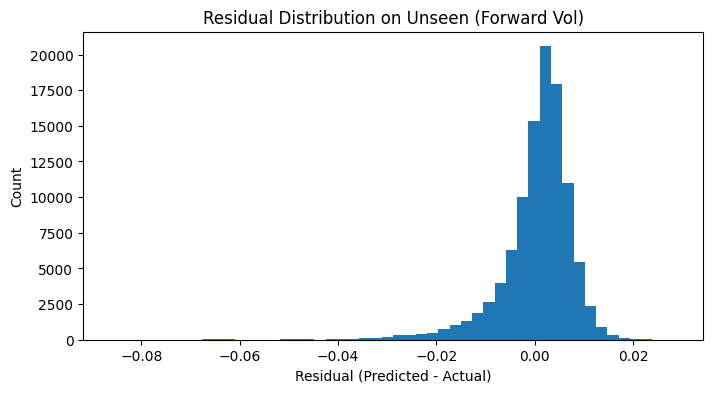

In [33]:
unseen_results["error"] = unseen_results["y_pred"] - unseen_results["y_true"]
unseen_residuals = unseen_results["error"]

plt.figure(figsize=(8, 4))
plt.hist(unseen_residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Count")
plt.show()

In [34]:
# results

unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

In [35]:
unseen_results = unseen_results.merge(
    unseen_feat[["Symbol", "Date", "ret_std_21", "Sector"]],
    on=["Symbol", "Date"],
    how="left"
)

unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

In [36]:
# stock-level insights

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rows = []
for symbol, g in unseen_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_lstm": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g)
    })

by_stock = pd.DataFrame(rows)
by_stock["rmse_win"] = by_stock["rmse_lstm"] < by_stock["rmse_baseline"]
by_stock["mae_win"] = by_stock["mae_lstm"] < by_stock["mae_baseline"]
by_stock["corr_win"] = by_stock["corr_lstm"] > by_stock["corr_baseline"]

print("Pct stocks where LSTM wins on RMSE:", by_stock["rmse_win"].mean())
print("Pct stocks where LSTM wins on MAE:", by_stock["mae_win"].mean())
print("Pct stocks where LSTM wins on corr:", by_stock["corr_win"].mean())

Pct stocks where LSTM wins on RMSE: 0.9038076152304609
Pct stocks where LSTM wins on MAE: 0.8657314629258517
Pct stocks where LSTM wins on corr: 0.6332665330661322


In [38]:
rows = []
for sector, g in unseen_results.groupby("Sector"):
    if len(g) < 20:
        continue
    rows.append({
        "Sector": sector,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_lstm": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g)
    })

by_sector = pd.DataFrame(rows)
by_sector["rmse_win"] = by_sector["rmse_lstm"] < by_sector["rmse_baseline"]
by_sector["mae_win"] = by_sector["mae_lstm"] < by_sector["mae_baseline"]
by_sector["corr_win"] = by_sector["corr_lstm"] > by_sector["corr_baseline"]

by_sector.sort_values("rmse_lstm")

,Sector,rmse_lstm,rmse_baseline,mae_lstm,mae_baseline,corr_lstm,corr_baseline,n_obs,rmse_win,mae_win,corr_win
10,Utilities,0.005307,0.006176,0.004091,0.003712,0.787601,0.693220,6479,True,False,True
3,Energy,0.005371,0.008388,0.004359,0.005581,0.548156,0.353205,4598,True,True,True
9,Real Estate,0.005544,0.006567,0.004185,0.004749,0.401613,0.319492,6479,True,True,True
2,Consumer Staples,0.005896,0.008183,0.004077,0.005442,0.473374,0.255887,7524,True,True,True
8,Materials,0.006502,0.009211,0.004917,0.006643,0.625224,0.453301,5434,True,True,True
6,Industrials,0.006558,0.009274,0.004832,0.006568,0.494553,0.315376,16302,True,True,True
4,Financials,0.007008,0.009395,0.004865,0.005934,0.534191,0.416915,15883,True,True,True
1,Consumer Discretionary,0.007168,0.010438,0.005130,0.007353,0.546424,0.353176,10032,True,True,True
5,Health Care,0.009313,0.012948,0.006163,0.008634,0.411818,0.224200,12331,True,True,True
7,Information Technology,0.009940,0.013554,0.006878,0.009590,0.558469,0.389072,14421,True,True,True


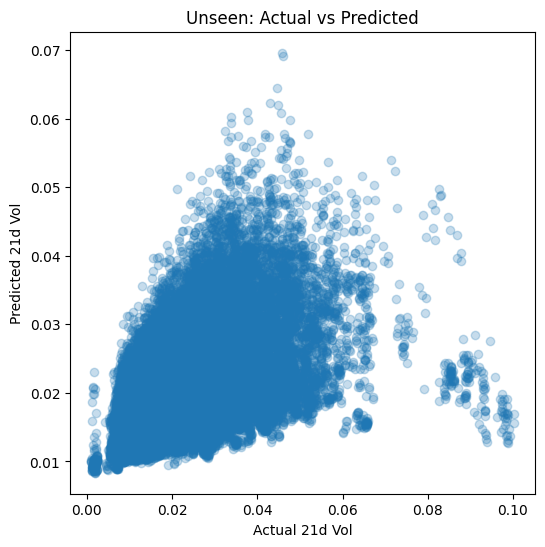

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(unseen_results["y_true"], unseen_results["y_pred"], alpha=0.25)
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Unseen: Actual vs Predicted")
plt.show()

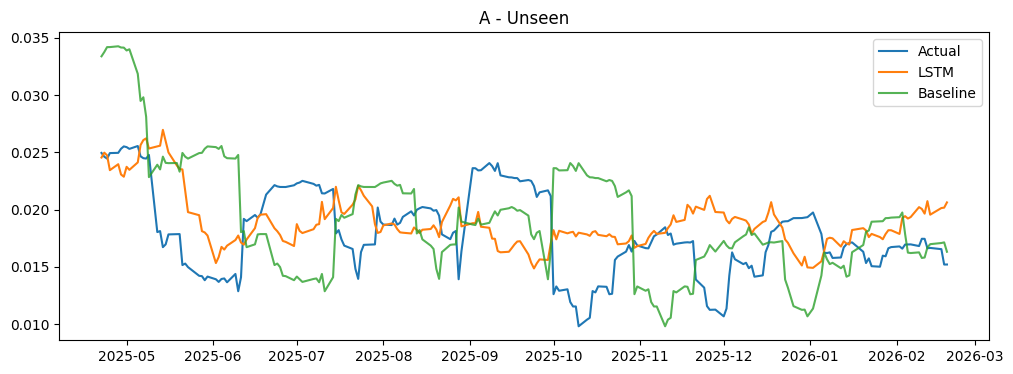

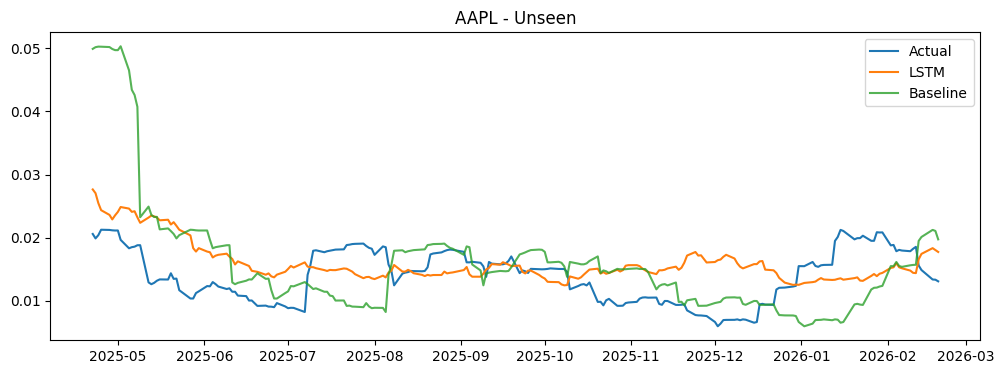

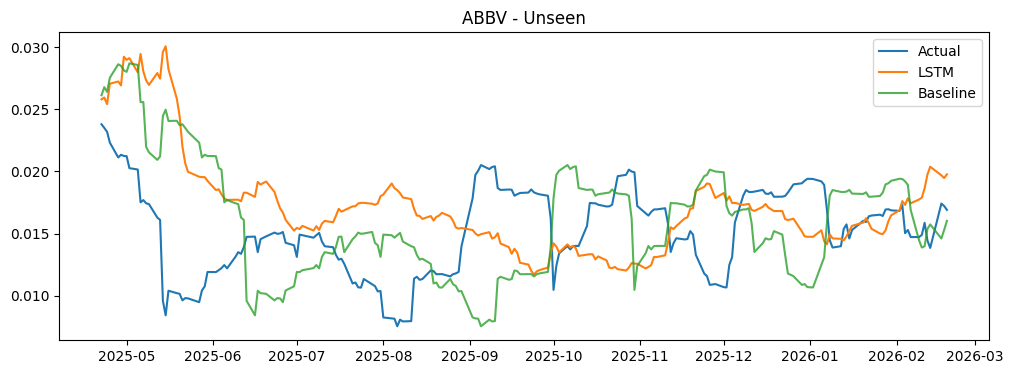

In [40]:
sample_symbols = unseen_results["Symbol"].drop_duplicates().head(3)

for symbol in sample_symbols:
    tmp = unseen_results[unseen_results["Symbol"] == symbol].sort_values("Date")
    plt.figure(figsize=(12, 4))
    plt.plot(tmp["Date"], tmp["y_true"], label="Actual")
    plt.plot(tmp["Date"], tmp["y_pred"], label="LSTM")
    plt.plot(tmp["Date"], tmp["baseline_pred"], label="Baseline", alpha=0.8)
    plt.title(f"{symbol} - Unseen")
    plt.legend()
    plt.show()

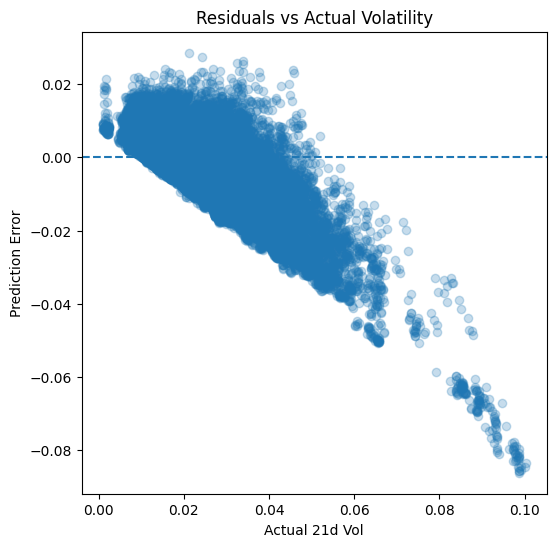

In [42]:
plt.figure(figsize=(6, 6))
error = unseen_results["y_pred"] - unseen_results["y_true"]
plt.scatter(unseen_results["y_true"], error, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Prediction Error")
plt.title("Residuals vs Actual Volatility")
plt.show()

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_scaled, y_true, y_mean, y_std):
    pred_scaled = model.predict(X_scaled, verbose=0).reshape(-1)
    pred = pred_scaled * y_std + y_mean
    
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    corr = pd.Series(y_true).corr(pd.Series(pred))
    
    return {"rmse": rmse, "mae": mae, "corr": corr}

# baseline validation performance
base_metrics = evaluate_model(model, X_val_scaled, y_val, y_mean, y_std)
print("Base metrics:", base_metrics)

# permutation importance
rng = np.random.default_rng(42)
importance_rows = []

for j, feature in enumerate(feature_cols):
    X_perm = X_val_scaled.copy()

    # shuffle this feature across samples, preserving the 21-step sequence within each sample
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, :, j] = X_perm[perm_idx, :, j]

    perm_metrics = evaluate_model(model, X_perm, y_val, y_mean, y_std)

    importance_rows.append({
        "feature": feature,
        "rmse_increase": perm_metrics["rmse"] - base_metrics["rmse"],
        "mae_increase": perm_metrics["mae"] - base_metrics["mae"],
        "corr_drop": base_metrics["corr"] - perm_metrics["corr"],
    })

importance_df = pd.DataFrame(importance_rows).sort_values(
    "rmse_increase", ascending=False
)

importance_df

Base metrics: {'rmse': np.float64(0.007182013574546647), 'mae': 0.0046423557214438915, 'corr': np.float64(0.6086625881503555)}


,feature,rmse_increase,mae_increase,corr_drop
4,hl_range_mean_5,0.001343,0.001350,0.240377
5,hl_range_mean_21,0.001115,0.001041,0.164262
3,ret_std_21,0.000359,0.000214,0.048801
1,ret_std_5,0.000270,0.000334,0.017066
0,ret_abs_1,0.000262,0.000381,0.036459
6,vol_rel_5,0.000153,0.000257,0.017607
2,ret_std_10,0.000111,0.000059,0.015370
7,vol_rel_21,0.000084,0.000135,0.012284


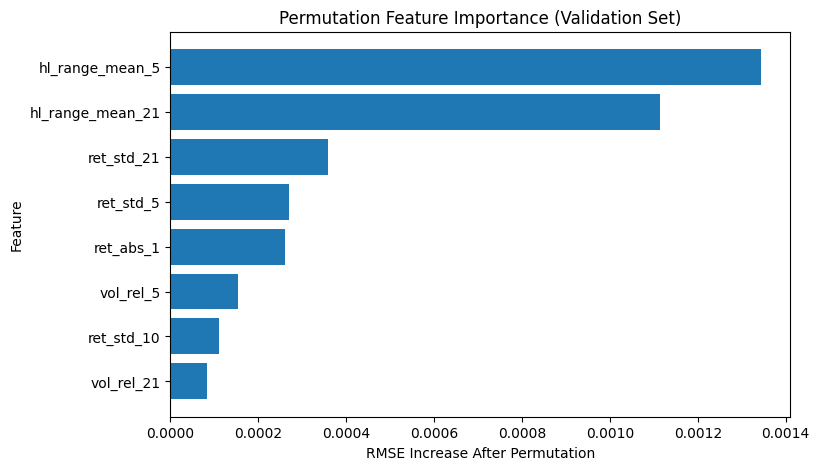

In [44]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values("rmse_increase", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["rmse_increase"])
plt.xlabel("RMSE Increase After Permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Validation Set)")
plt.show()